# Phase 7 — Limited Exploratory Forecasting

**Purpose:** execute the pre-planned counterfactual component. **Not** a search for a
PLI effect. The standing conclusion — *"no basket shows a trajectory change that
survives the pre-specified robustness framework"* — is **not subject to revision** by
anything in this notebook.

**Binding labels:** every gap below is **"actual minus pre-policy time-series
counterfactual"** — never a PLI effect, impact, treatment effect, or causal estimate.
No significance testing is performed on gaps.

**Locked protocol** (see `forecast_core.py` docstring): pre-policy data only for
training and selection; candidates = seasonal naive, ETS (add/add/add, damped and
undamped) and the single pre-declared SARIMA(0,1,1)(0,1,1)[12] airline specification
(admitted on Phase-4 seasonal-autocorrelation diagnostics; no order search);
expanding-origin validation with m=30; selection = lowest RMSE of 12-step errors
subject to pooled 95% coverage in [0.85, 1.00]; h=12 primary, h=6 secondary, h=18 for
B4 only. **B1 = seasonal-naive benchmark only, NOT model-selected** (28 pre-policy
months; training window ends in the COVID-distorted period; no substantive
counterfactual claim).

**Pre-stated for B3, before any gap is shown:** its training window ends March 2022 —
exactly where R12 locates smooth trend acceleration. A large B3 gap therefore
*restates the already-documented curvature* and must not be read as evidence of PLI
impact.

In [1]:
import warnings; warnings.filterwarnings("ignore")
import pandas as pd, numpy as np
import its_core as I, forecast_core as F
pd.set_option("display.width", 240)
df = I.load_panel()
NPRE = {"B1_MOBILE": 28, "B2_PHARMA": 48, "B3_AC": 48, "B4_TEXTILE": 72}
print("horizons:", F.HORIZONS, "| m =", F.M_MIN)
print("origins at h=12:", {b: NPRE[b]-12-F.M_MIN+1 if NPRE[b]-12-F.M_MIN+1>0 else 0 for b in NPRE})

# inline display of figures saved to ../07_figures (same files, no duplicates)
from IPython.display import Image, display
def show(figs):
    if figs is None: return
    if isinstance(figs, str): figs = [figs]
    for f in figs:
        if f: display(Image(filename=f"../07_figures/{f}"))

horizons: {'B1_MOBILE': [6, 12], 'B2_PHARMA': [6, 12], 'B3_AC': [6, 12], 'B4_TEXTILE': [6, 12, 18]} | m = 30
origins at h=12: {'B1_MOBILE': 0, 'B2_PHARMA': 7, 'B3_AC': 7, 'B4_TEXTILE': 31}


## 1. Validation — pre-policy only

**Mandatory disclosure:** B2 and B3 have only **7** rolling-origin validation origins
at h=12. Model selection for them is weakly identified and the resulting
counterfactuals are exploratory. B4, with **31** origins, is the only well-validated
case and the only basket where this exercise is a genuinely useful methodological
demonstration.

In [2]:
val, sel, tabs = [], {}, {}
for b in ["B2_PHARMA", "B3_AC", "B4_TEXTILE"]:
    s = df[df.basket_id == b].set_index("date").asfreq("MS")
    y = np.log(s["y"]); y.index = s.index
    recs = F.validate(y.iloc[:NPRE[b]], max(F.HORIZONS[b]))
    chosen, tab, fb = F.select(recs)
    sel[b], tabs[b] = (chosen, fb), (recs, tab)
    print(b, "-> raw RMSE winner:", chosen, "(coverage fallback)" if fb else "")
    print(tab[["model","n_origins","rmse","mae","mape","cov95_pooled"]].round(4).to_string(index=False), "\n")
    for h in F.HORIZONS[b]:
        for _, r in F.metrics(recs, h).iterrows():
            val.append(dict(basket=b, **r))
pd.DataFrame(val).round(4).to_csv("../06_results/forecast_validation.csv", index=False)
print("forecast_validation.csv written:", len(val), "rows")

B2_PHARMA -> raw RMSE winner: snaive 
         model  n_origins   rmse    mae   mape  cov95_pooled
           ets          7 0.1673 0.1581 2.1791        0.4832
    ets_damped          7 0.1094 0.0949 1.3113        0.7785
sarima_airline          7 0.1725 0.1630 2.2464        0.8389
        snaive          7 0.0706 0.0565 0.7793        0.9530 



B3_AC -> raw RMSE winner: sarima_airline 
         model  n_origins   rmse    mae    mape  cov95_pooled
           ets          7 0.6230 0.6207 20.4699         0.953
    ets_damped          7 0.4073 0.4041 13.2838         0.953
sarima_airline          7 0.2646 0.2374  7.8770         0.953
        snaive          7 0.2715 0.2481  8.1663         0.953 



B4_TEXTILE -> raw RMSE winner: ets_damped 
         model  n_origins   rmse    mae   mape  cov95_pooled
           ets         31 0.3987 0.3116 6.9876        0.9703
    ets_damped         31 0.1521 0.1320 2.9449        0.9817
sarima_airline         31 0.3185 0.2531 5.6647        0.9977
        snaive         31 0.1550 0.1323 2.9537        0.9840 

forecast_validation.csv written: 28 rows


## 2. The locked tie-break clause, applied

Memo §4.5 (locked): *"Where the RMSE gap between the winner and the seasonal-naive
benchmark is small relative to its spread across origins, say so explicitly and
prefer the simpler model."* Operationalised mechanically (declared before computing):
paired per-origin |12-step error| differences; **prefer seasonal naive if the paired
t-statistic < 1.**

In [3]:
for b, cand in [("B3_AC", "sarima_airline"), ("B4_TEXTILE", "ets_damped")]:
    recs, _ = tabs[b]
    d = recs[recs.h == 12].pivot(index="origin", columns="model", values="abs_err").dropna()
    diff = d["snaive"] - d[cand]
    t = diff.mean() / (diff.std(ddof=1) / np.sqrt(len(diff)))
    print(f"{b}: snaive - {cand} paired diff = {diff.mean():+.4f}, t = {t:+.2f} "
          f"-> {'keep ' + cand if t >= 1 else 'PREFER SEASONAL NAIVE'}")
print("\nFINAL SELECTION: seasonal naive for ALL baskets")
print("  B1: locked (benchmark only, not model-selected)")
print("  B2: outright lowest RMSE, coverage 0.953")
print("  B3: tie-break (SARIMA win indistinguishable across 7 origins, t=0.45)")
print("  B4: tie-break (ETS-damped win indistinguishable across 31 origins, t=0.03)")

B3_AC: snaive - sarima_airline paired diff = +0.0107, t = +0.45 -> PREFER SEASONAL NAIVE
B4_TEXTILE: snaive - ets_damped paired diff = +0.0002, t = +0.03 -> PREFER SEASONAL NAIVE

FINAL SELECTION: seasonal naive for ALL baskets
  B1: locked (benchmark only, not model-selected)
  B2: outright lowest RMSE, coverage 0.953
  B3: tie-break (SARIMA win indistinguishable across 7 origins, t=0.45)
  B4: tie-break (ETS-damped win indistinguishable across 31 origins, t=0.03)


## 3. Counterfactuals — selected model frozen, trained on the full pre-policy window

Post-policy data was **never** used in selection. Raw-RMSE-winner counterfactuals for
B3/B4 are retained in the CSV for transparency, flagged as superseded by the tie-break.

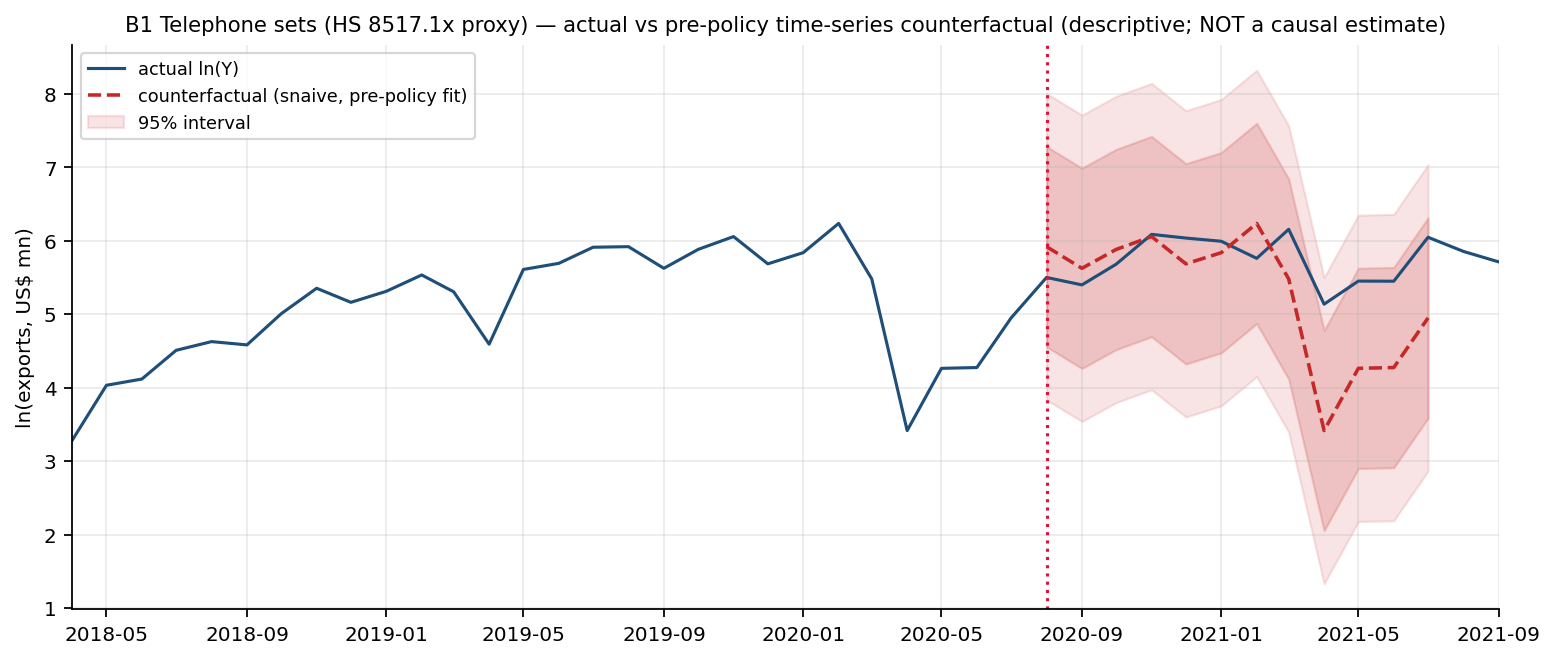

B1_MOBILE   h=12  mean gap   +42.3 lgp  cum  +23.2%  outside 95% PI: 0/12


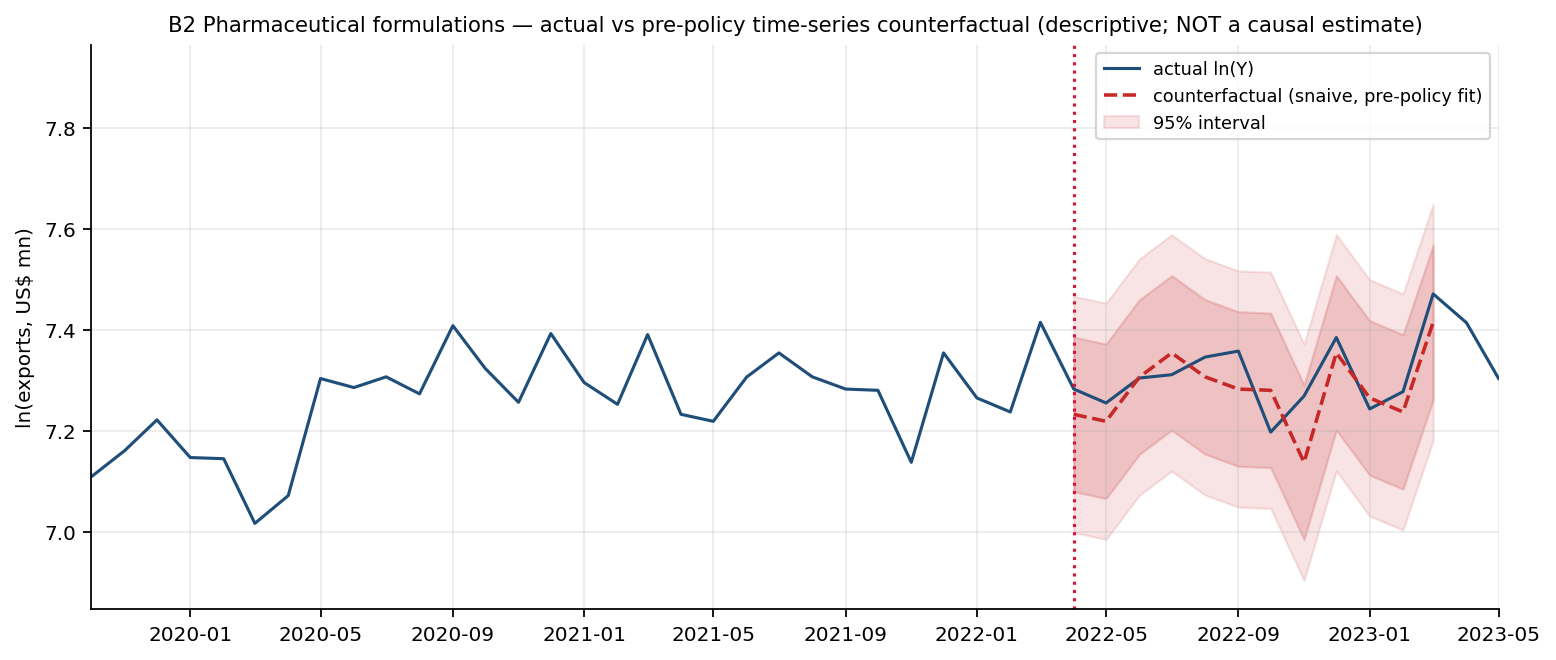

B2_PHARMA   h=12  mean gap    +2.6 lgp  cum   +2.6%  outside 95% PI: 0/12


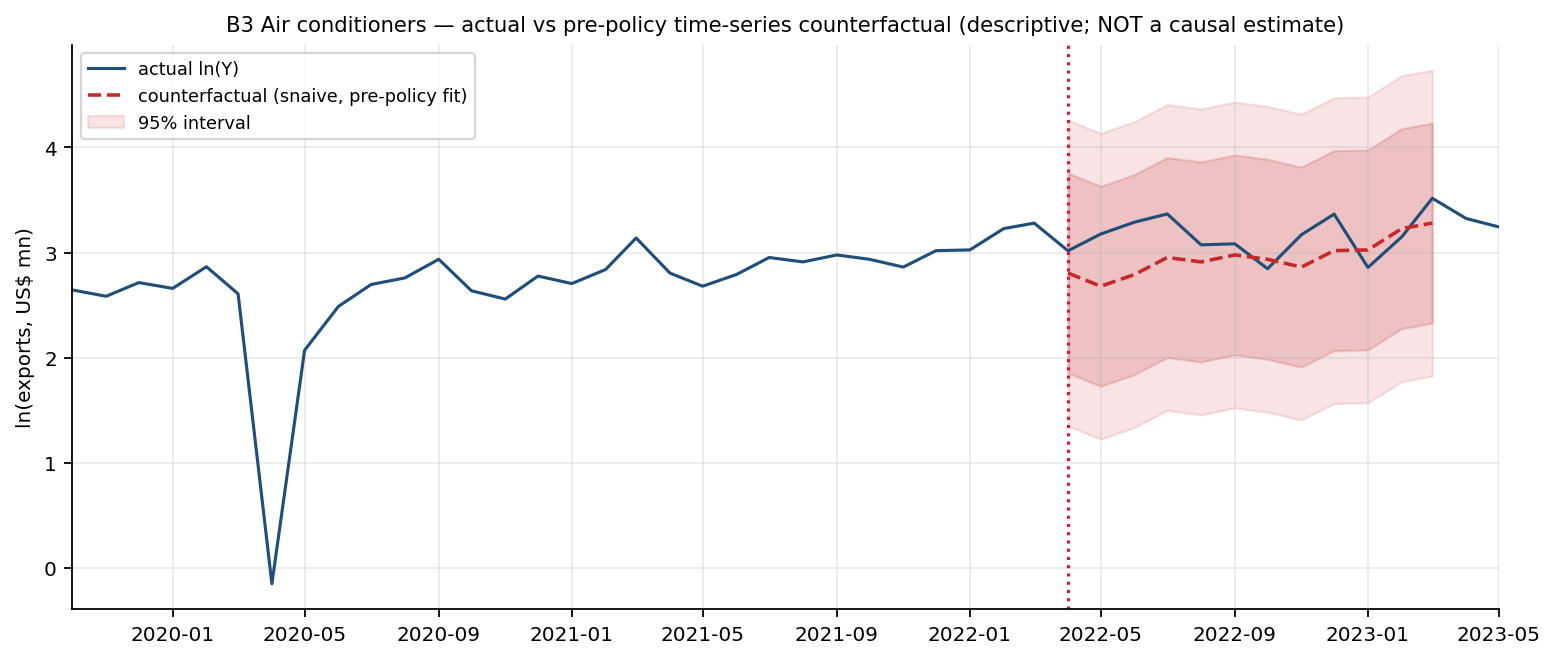

B3_AC       h=12  mean gap   +20.4 lgp  cum  +23.2%  outside 95% PI: 0/12


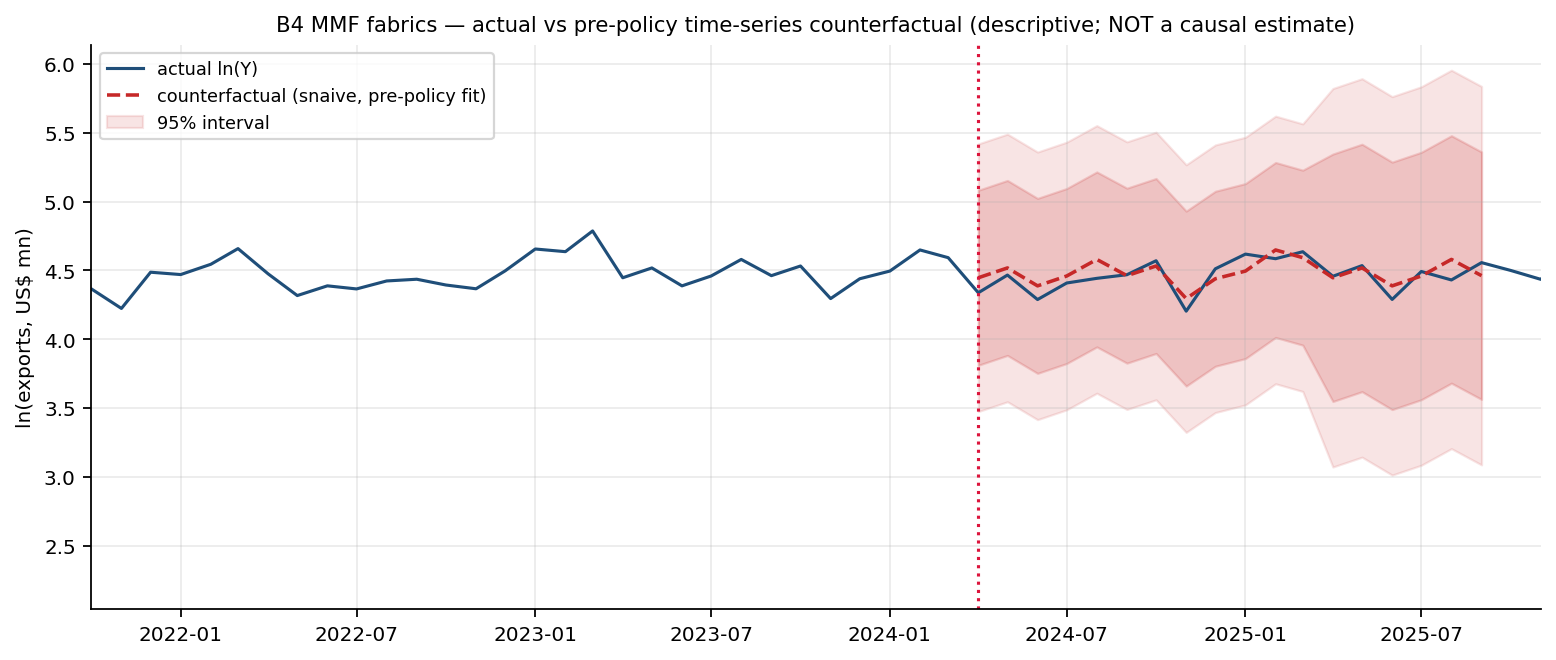

B4_TEXTILE  h=12  mean gap    -2.7 lgp  cum   -2.2%  outside 95% PI: 0/12
forecast_counterfactual.csv written: 84 rows (FINAL + raw-winner variants)


,basket,month,h,model,actual_lnY,cf_lnY,cf_lo95,cf_hi95,cf_lo80,cf_hi80,actual_usd,cf_usd,gap_log_pts,gap_pct,inside_95,selection,selection_note
0,B1_MOBILE,2020-08,1,snaive,5.5002,5.9196,3.8337,8.0055,4.5557,7.2835,244.74,372.25,-41.94,-34.3,True,FINAL,"LOCKED: benchmark only, not model-selected"
1,B1_MOBILE,2020-09,2,snaive,5.3991,5.6250,3.5391,7.7108,4.2611,6.9888,221.20,277.26,-22.59,-20.2,True,FINAL,"LOCKED: benchmark only, not model-selected"
2,B1_MOBILE,2020-10,3,snaive,5.6814,5.8822,3.7963,7.9681,4.5183,7.2461,293.37,358.59,-20.07,-18.2,True,FINAL,"LOCKED: benchmark only, not model-selected"
3,B1_MOBILE,2020-11,4,snaive,6.0871,6.0570,3.9711,8.1429,4.6931,7.4209,440.15,427.09,3.01,3.1,True,FINAL,"LOCKED: benchmark only, not model-selected"
4,B1_MOBILE,2020-12,5,snaive,6.0367,5.6856,3.5997,7.7715,4.3217,7.0495,418.51,294.60,35.11,42.1,True,FINAL,"LOCKED: benchmark only, not model-selected"


In [4]:
FINAL = {"B1_MOBILE": ("snaive", "LOCKED: benchmark only, not model-selected"),
         "B2_PHARMA": ("snaive", "selected: lowest RMSE outright, coverage 0.953"),
         "B3_AC": ("snaive", "tie-break: sarima_airline RMSE win not distinguishable across origins (paired t=0.45) -> locked clause prefers simpler"),
         "B4_TEXTILE": ("snaive", "tie-break: ets_damped RMSE win not distinguishable across origins (paired t=0.03) -> locked clause prefers simpler")}
RAW = {"B3_AC": "sarima_airline", "B4_TEXTILE": "ets_damped"}   # retained for transparency
cf_all = []
for b in FINAL:
    s = df[df.basket_id == b].set_index("date").asfreq("MS")
    y = np.log(s["y"]); y.index = s.index
    hmax = max(F.HORIZONS[b])
    model, why = FINAL[b]
    cf = F.counterfactual(y, NPRE[b], model, hmax)
    cf.insert(0, "basket", b); cf["selection"] = "FINAL"; cf["selection_note"] = why
    cf_all.append(cf)
    show(F.plot_cf(y, NPRE[b], cf, b, model, I.D_S[b]))
    if b in RAW:
        cfr = F.counterfactual(y, NPRE[b], RAW[b], hmax); cfr.insert(0, "basket", b)
        cfr["selection"] = "raw_rmse_winner"
        cfr["selection_note"] = f"{RAW[b]} - retained for transparency; superseded by tie-break"
        cf_all.append(cfr)
    g = cf[cf.h <= 12]
    print(f"{b:11s} h=12  mean gap {g.gap_log_pts.mean():+7.1f} lgp  "
          f"cum {100*(g.actual_usd.sum()/g.cf_usd.sum()-1):+6.1f}%  "
          f"outside 95% PI: {(~g.inside_95.astype(bool)).sum()}/12")
CF = pd.concat(cf_all, ignore_index=True)
CF.to_csv("../06_results/forecast_counterfactual.csv", index=False)
print(f"forecast_counterfactual.csv written: {len(CF)} rows (FINAL + raw-winner variants)")
CF.head()

## 4. Reading — descriptive only

**Every actual observation lies inside the 95% counterfactual interval, in every
basket, at every horizon.** No gap exceeds pre-policy forecast uncertainty.

- **B1** (+23% cumulative at h=12): benchmark-only, 28 COVID-ending pre-months —
  **no substantive counterfactual claim is made.**
- **B2** (+2.6%): actuals hug the counterfactual.
- **B3** (+23% at h=12, +37% at h=6): the pre-stated expectation realised — this gap
  **restates the smooth acceleration R12 already identified.** Not evidence of PLI
  impact.
- **B4** (−2.2% at h=12, −1.9% at h=18): the best-validated case shows actuals
  slightly *below* the counterfactual.

A large gap does not establish a PLI effect; a small gap does not prove PLI had no
effect. **Forecasting provides no causal identification.** The standing conclusion is
unchanged.

Outputs: `forecast_validation.csv`, `forecast_counterfactual.csv`, `fc_01_*` figures, `FORECASTING_findings.md`.